##Package Installation & setup

In [ ]:
!pip install pandas fastparquet

import pandas as pd
import matplotlib.pyplot as plt
import io
import requests
import numpy as np
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.3 MB/s eta 0:00:00


In [ ]:
drive.mount('/content/gdrive', force_remount=True)
df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/processed_data.csv')

Mounted at /content/gdrive


##Data Cleansing
(no need to run anymore)

Crop Prodction Dataset

In [ ]:
# Define the URL of the CSV file
url = 'https://storage.data.gov.my/agriculture/crops_district_production.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(url)

# Convert the 'date' column to datetime format if it exists
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

# Display the first few rows of the DataFrame
print(df.head())
print(df.info())

        date  state    district   crop_type  crop_species  production
0 2017-01-01  Johor  Batu Pahat  cash_crops       cassava       920.5
1 2017-01-01  Johor  Batu Pahat  cash_crops    groundnuts         0.0
2 2017-01-01  Johor  Batu Pahat  cash_crops    sweet_corn         0.0
3 2017-01-01  Johor  Batu Pahat  cash_crops  sweet_potato       350.0
4 2017-01-01  Johor  Batu Pahat  cash_crops           yam       395.4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11002 entries, 0 to 11001
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          11002 non-null  datetime64[ns]
 1   state         11002 non-null  object        
 2   district      11002 non-null  object        
 3   crop_type     11002 non-null  object        
 4   crop_species  11002 non-null  object        
 5   production    11002 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 515.8+ KB

In [ ]:
# Check how many zeros in 'production'

print(df['production'].value_counts().sort_index())
print("Number of zeros in production:", (df['production'] == 0).sum())

production
0.0000         5556
0.0020            1
0.0063            1
0.0100            1
0.0300            1
               ... 
76374.8490        1
97330.5940        1
117093.0000       1
163620.4000       1
175141.7500       1
Name: count, Length: 3600, dtype: int64
Number of zeros in production: 5556


In [ ]:
# 1. Handle missing values

# Check missing data count
print("\nMissing values per column:")
print(df.isna().sum())

# Strategy:
# - Drop rows where essential columns are missing (e.g., 'state', 'district', 'crop_type', 'production')
# - For non-essential columns, you could fill missing values or leave as is depending on context

essential_cols = ['state', 'district', 'crop_type', 'production']
df_clean = df.dropna(subset=essential_cols)


Missing values per column:
date            0
state           0
district        0
crop_type       0
crop_species    0
production      0
dtype: int64


In [ ]:
# 2. Convert data types

# Convert 'date' column to datetime if not already
if 'date' in df_clean.columns:
    df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')

# Check if 'production' is numeric; convert if necessary
df_clean['production'] = pd.to_numeric(df_clean['production'], errors='coerce')

# Remove rows where 'production' conversion failed (NaN values)
df_clean = df_clean.dropna(subset=['production'])

In [ ]:
# 3. Remove duplicates if any
df_clean = df_clean.drop_duplicates()

In [ ]:
# 4. Strip whitespace from string columns (like state, district, crop_type)
for col in ['state', 'district', 'crop_type', 'crop_species']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

In [ ]:
# 5. Basic sanity checks

# Production should be non-negative
df_clean = df_clean[df_clean['production'] > 0]

print("\nCleaned data info:")
print(df_clean.info())
print("\nSample cleaned data:")
print(df_clean.head())


Cleaned data info:
<class 'pandas.core.frame.DataFrame'>
Index: 5446 entries, 0 to 11001
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          5446 non-null   datetime64[ns]
 1   state         5446 non-null   object        
 2   district      5446 non-null   object        
 3   crop_type     5446 non-null   object        
 4   crop_species  5446 non-null   object        
 5   production    5446 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 297.8+ KB
None

Sample cleaned data:
        date  state    district   crop_type  crop_species  production
0 2017-01-01  Johor  Batu Pahat  cash_crops       cassava      920.50
3 2017-01-01  Johor  Batu Pahat  cash_crops  sweet_potato      350.00
4 2017-01-01  Johor  Batu Pahat  cash_crops           yam      395.40
7 2017-01-01  Johor  Batu Pahat       fruit        banana     9856.11
8 2017-01-01  Johor  Batu Pa

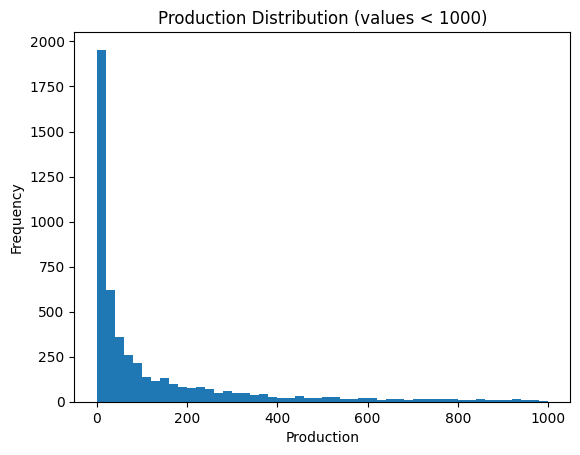

In [ ]:
# Histogram including zeros (excluding extreme outliers)
plt.hist(df_clean['production'][df_clean['production'] < 1000], bins=50)
plt.title('Production Distribution (values < 1000)')
plt.xlabel('Production')
plt.ylabel('Frequency')
plt.show()

Weather Dataset

from Kaggle: [full_weather.csv](https://www.kaggle.com/datasets/shahmirvarqha/weather-data-malaysia?select=full_weather.csv)

In [ ]:
# Import dataset from Google Drive
drive.mount('/content/gdrive', force_remount=True)
file_path = "/content/gdrive/MyDrive/Colab Notebooks/full_weather.csv"
weather_df = pd.read_csv (file_path, header=0)
print(weather_df.head())
print(weather_df.info())

# Determine the datatype of Each Column by using dtypes
print (weather_df.dtypes)

Mounted at /content/gdrive
              datetime         place           city         state  \
0  1996-08-09 13:30:00   Tanjung Aru  Kota Kinabalu         Sabah   
1  1996-08-09 13:30:00    Batu Maung    Bayan Lepas  Pulau Pinang   
2  1996-08-09 13:30:00        Sepang         Sepang  Kuala Lumpur   
3  1996-08-09 13:30:00  Kota Sentosa        Kuching       Sarawak   
4  1996-08-09 14:30:00        Sepang         Sepang  Kuala Lumpur   

   temperature  pressure  dew_point  humidity  wind_speed  gust  wind_chill  \
0         32.0   1006.16       25.0      66.0         9.0   NaN        32.0   
1         25.0   1008.64       24.0      94.0         4.0   NaN        25.0   
2         29.0   1006.97       23.0      70.0         2.0   NaN        29.0   
3         33.0   1003.78       24.0      59.0         NaN   NaN        33.0   
4          NaN       NaN        NaN       NaN         7.0   NaN         NaN   

   uv_index  feels_like_temperature  visibility  solar_radiation  \
0       NaN    

In [ ]:
print("Find missing value of each column using isna()")
print (weather_df.isna().sum())

Find missing value of each column using isna()
datetime                         0
place                            0
city                             0
state                            0
temperature                5872234
pressure                   6204703
dew_point                  6062004
humidity                   5943500
wind_speed                 7713761
gust                      12595940
wind_chill                 6391615
uv_index                  11142125
feels_like_temperature    19286279
visibility                19357182
solar_radiation           14014888
pollutant_value           19131487
precipitation_rate        10836783
precipitation_total       10498288
dtype: int64


In [ ]:
# Check the % of missing values
missing_percent = weather_df.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print(missing_percent)

visibility                78.945379
feels_like_temperature    78.656212
pollutant_value           78.024916
solar_radiation           57.157630
gust                      51.370662
uv_index                  45.441495
precipitation_rate        44.196203
precipitation_total       42.815702
wind_speed                31.459424
wind_chill                26.067248
pressure                  25.304956
dew_point                 24.722979
humidity                  24.239678
temperature               23.949030
place                      0.000000
datetime                   0.000000
state                      0.000000
city                       0.000000
dtype: float64


In [ ]:
# Drop columns with too many missing values
weather_df_clean = weather_df.drop(columns=[
    'visibility',
    'feels_like_temperature',
    'pollutant_value',
    'solar_radiation',
    'gust',
    'uv_index',
    'precipitation_rate',
    'precipitation_total'
])

# Sort by datetime for proper time-based interpolation
weather_df_clean = weather_df_clean.sort_values('datetime')

# Interpolate missing values in selected numerical columns
cols_to_interpolate = ['wind_speed', 'wind_chill', 'pressure', 'dew_point', 'humidity', 'temperature']
weather_df_clean[cols_to_interpolate] = weather_df_clean[cols_to_interpolate].interpolate(method='linear')

# Drop any remaining rows with missing values (if any)
weather_df_clean = weather_df_clean.dropna()

# Optional: Reset index after cleaning
weather_df_clean = weather_df_clean.reset_index(drop=True)

# Preview the cleaned DataFrame
weather_df_clean.info()
weather_df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24519715 entries, 0 to 24519714
Data columns (total 10 columns):
 #   Column       Dtype  
---  ------       -----  
 0   datetime     object 
 1   place        object 
 2   city         object 
 3   state        object 
 4   temperature  float64
 5   pressure     float64
 6   dew_point    float64
 7   humidity     float64
 8   wind_speed   float64
 9   wind_chill   float64
dtypes: float64(6), object(4)
memory usage: 1.8+ GB


,datetime,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,wind_chill
0,1996-08-09 13:30:00,Tanjung Aru,Kota Kinabalu,Sabah,32.0,1006.16,25.0,66.0,9.0,32.0
1,1996-08-09 13:30:00,Batu Maung,Bayan Lepas,Pulau Pinang,25.0,1008.64,24.0,94.0,4.0,25.0
2,1996-08-09 13:30:00,Sepang,Sepang,Kuala Lumpur,29.0,1006.97,23.0,70.0,2.0,29.0
3,1996-08-09 13:30:00,Kota Sentosa,Kuching,Sarawak,33.0,1003.78,24.0,59.0,4.5,33.0
4,1996-08-09 14:30:00,Sepang,Sepang,Kuala Lumpur,29.0,1005.71,24.0,76.5,7.0,29.0


Combining two dataset (Crop Production + Weather)

In [ ]:
# 1. Crop data datetime processing
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# 2. Weather data datetime processing
weather_df_clean['datetime'] = pd.to_datetime(weather_df_clean['datetime'])
weather_df_clean['year'] = weather_df_clean['datetime'].dt.year
weather_df_clean['month'] = weather_df_clean['datetime'].dt.month

In [ ]:
# 3. Aggregate seasonal weather features
temp_avg = weather_df_clean[
    (weather_df_clean['month'] >= 6) & (weather_df_clean['month'] <= 8)
].groupby(['place', 'year'])['temperature'].mean().reset_index()

humidity_max = weather_df_clean[
    (weather_df_clean['month'] >= 5) & (weather_df_clean['month'] <= 7)
].groupby(['place', 'year'])['humidity'].max().reset_index()

wind_speed_avg = weather_df_clean[
    (weather_df_clean['month'] >= 5) & (weather_df_clean['month'] <= 9)
].groupby(['place', 'year'])['wind_speed'].mean().reset_index()


In [ ]:
# 4. Merge weather features into one DataFrame
weather_seasonal = temp_avg.merge(humidity_max, on=['place', 'year']) \
                           .merge(wind_speed_avg, on=['place', 'year'])

# 5. Merge with crop data (assuming df has 'district' and 'year' columns)
df_combined = pd.merge(df, weather_seasonal, how='left', left_on=['district', 'year'], right_on=['place', 'year'])

# 6. Drop the duplicate 'place' column after merge
df_combined = df_combined.drop(columns=['place'])

# 7. Drop rows with missing values in important columns
df_combined = df_combined.dropna(subset=['temperature', 'humidity', 'wind_speed', 'production'])

print(df_combined.head())

        date  state    district   crop_type  crop_species  production  year  \
0 2017-01-01  Johor  Batu Pahat  cash_crops       cassava       920.5  2017   
1 2017-01-01  Johor  Batu Pahat  cash_crops    groundnuts         0.0  2017   
2 2017-01-01  Johor  Batu Pahat  cash_crops    sweet_corn         0.0  2017   
3 2017-01-01  Johor  Batu Pahat  cash_crops  sweet_potato       350.0  2017   
4 2017-01-01  Johor  Batu Pahat  cash_crops           yam       395.4  2017   

   temperature  humidity  wind_speed  
0    28.841935     100.0    4.258515  
1    28.841935     100.0    4.258515  
2    28.841935     100.0    4.258515  
3    28.841935     100.0    4.258515  
4    28.841935     100.0    4.258515  


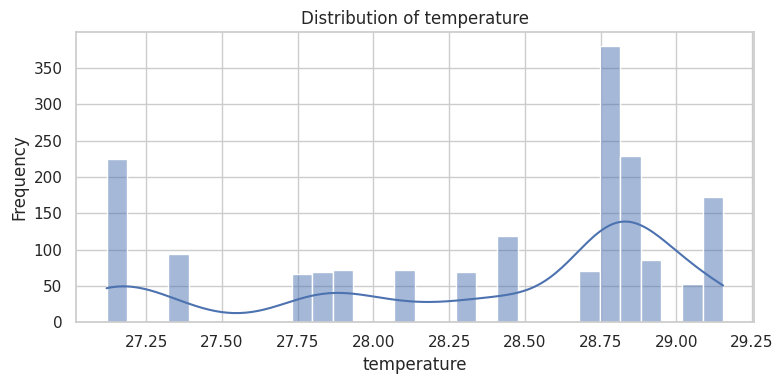

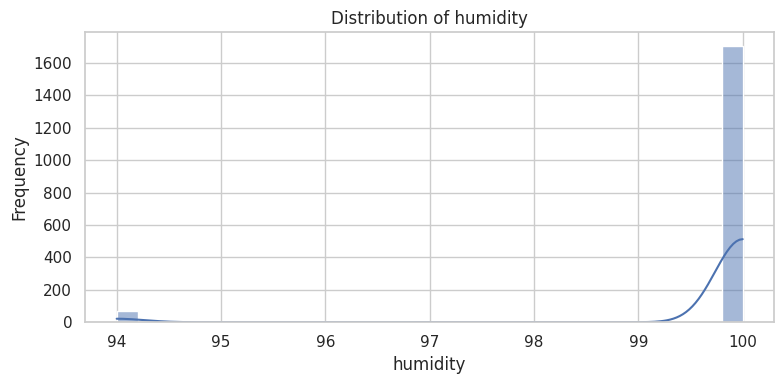

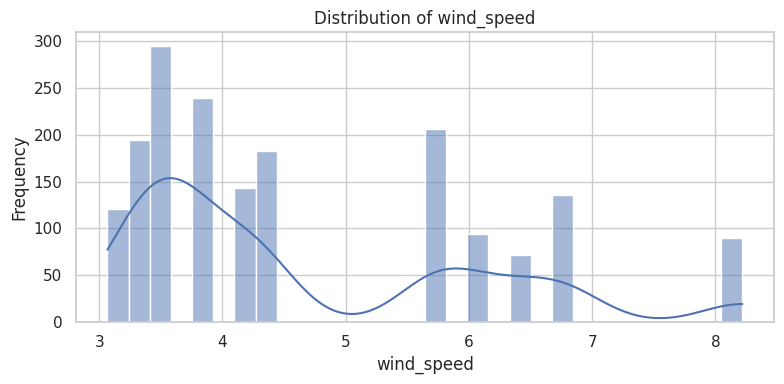

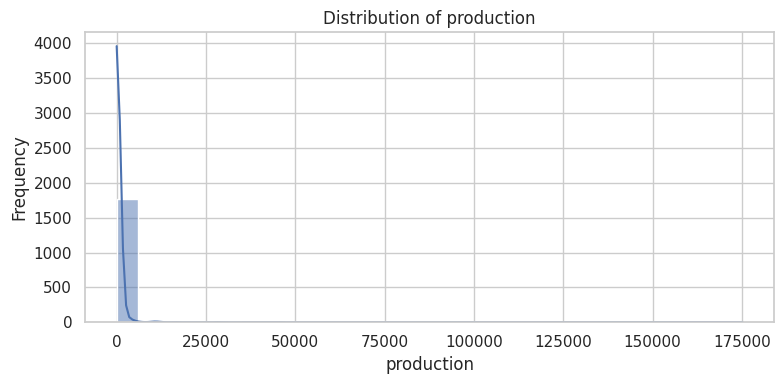

In [ ]:
# Set style for better appearance
sns.set(style="whitegrid")

# Create histograms for key features
features = ['temperature', 'humidity', 'wind_speed', 'production']

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_combined[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [ ]:
# 4. Save cleaned data to CSV on Google Drive or local disk
df_combined.to_csv('/content/gdrive/MyDrive/Colab Notebooks/processed_data.csv', index=False)

##Data Distribution

In [ ]:
def plot_categorical_distribution(column_name, data=df):
    plt.figure(figsize=(10, 4))

    # Bar chart
    plt.subplot(1, 2, 1)
    sns.countplot(y=column_name, data=data, palette='muted')
    plt.title(f'Distribution of {column_name}')

    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='center', va='center', xytext=(10, 0), textcoords='offset points')

    sns.despine(left=True, bottom=True)

    # Pie chart
    plt.subplot(1, 2, 2)
    data[column_name].value_counts().plot.pie(
        autopct='%1.1f%%',
        colors=sns.color_palette('muted'),
        startangle=90,
        explode=[0.05]*data[column_name].nunique(),
        textprops={'fontsize': 8}  # 👈 control font size here
    )
    plt.title(f'Percentage Distribution of {column_name}')
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

<ipython-input-29-bffa9aa0170e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


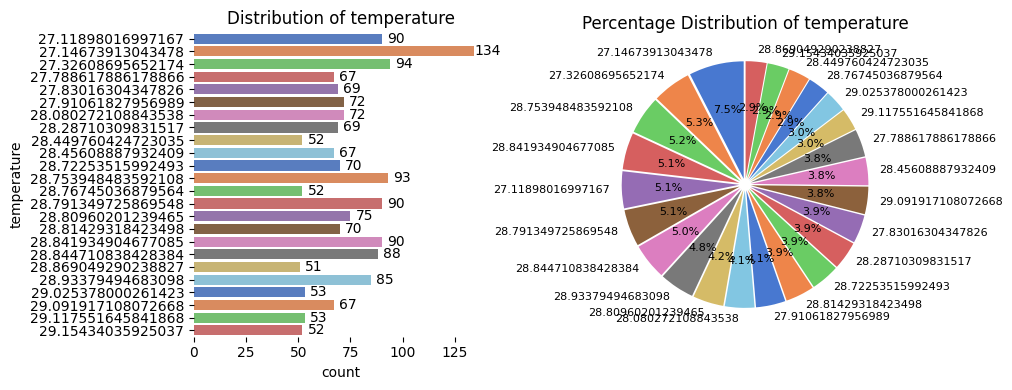

<ipython-input-29-bffa9aa0170e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


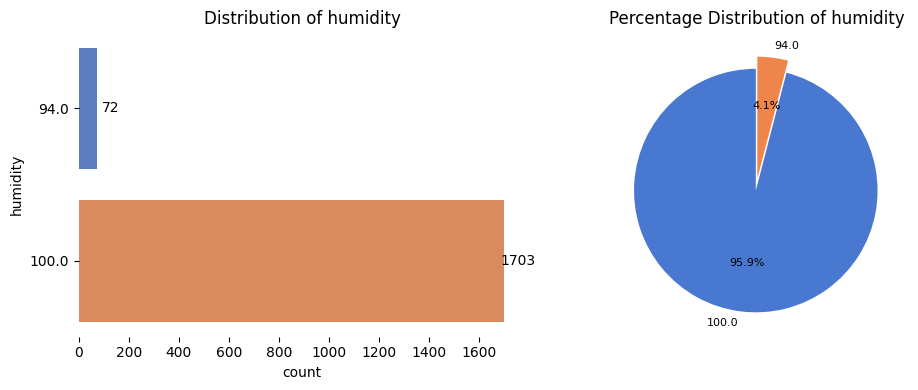

<ipython-input-29-bffa9aa0170e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


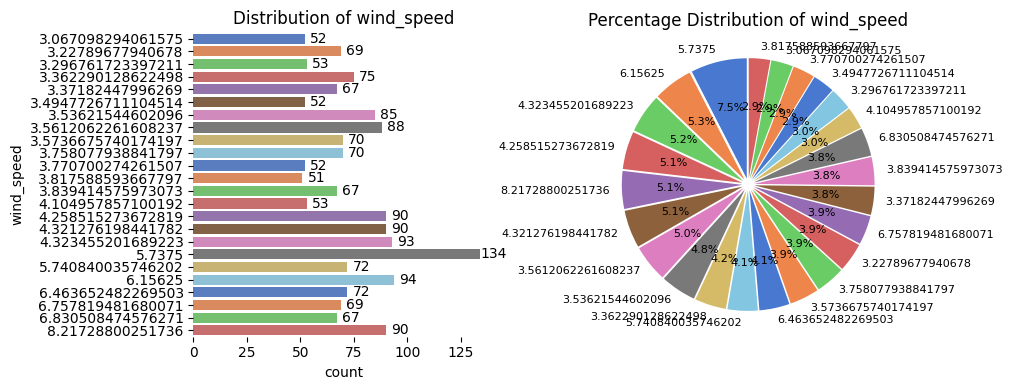

In [ ]:
plot_categorical_distribution('temperature')
plot_categorical_distribution('humidity')
plot_categorical_distribution('wind_speed')

##Data Normalisation

In [ ]:
# Features
features = ['temperature', 'humidity', 'wind_speed']
X = df[features]
y = df['production']

In [ ]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)